# Exploring EmFit Value Added Catalog

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import fitsio

In [2]:
columns_to_read = [
    "TARGETID", 
    "TARGET_RA",
    "TARGET_DEC",
    "Z",
    "HBETA_FLUX",
    "HBETA_FLUXERR",
    "OIII5007_FLUX",
    "OIII5007_FLUXERR",
    "HALPHA_FLUX",
    "HALPHA_FLUXERR",
    "NII6583_FLUX",
    "NII6583_FLUXERR",
    ]

vac_fname = "~/Downloads/dr1_galaxy_stellarmass_lineinfo_v1.0.fits"
data = fitsio.read(vac_fname, ext=1, columns=columns_to_read)

# The following is necessary to avoid and endianness problem
vac = pd.DataFrame({
    col: np.asarray(data[col], dtype=data[col].dtype.newbyteorder('<'))
    for col in data.dtype.names
})

In [3]:
selection = vac.query("NII6583_FLUX / NII6583_FLUXERR > 2 "
                      "and Z < 0.15 "
                      "and OIII5007_FLUX > 0 "
                      "and HALPHA_FLUX > 0 "
                      "and TARGET_DEC < 10")

In [4]:
selection[['NII6583_FLUX', 'OIII5007_FLUX', 'HBETA_FLUX', 'HALPHA_FLUX']].describe()

,NII6583_FLUX,OIII5007_FLUX,HBETA_FLUX,HALPHA_FLUX
count,370895.000000,3.708950e+05,370895.000000,370895.000000
mean,45.548630,6.062558e+01,38.961924,148.882674
std,106.040047,3.166554e+02,1442.639518,294.552724
min,0.402744,2.681901e-42,-876880.189213,0.111550
25%,11.602167,9.158563e+00,13.482143,46.336998
50%,22.702402,1.897076e+01,24.386149,84.731861
75%,46.847539,4.458967e+01,44.454963,159.620988
max,12236.535829,6.426101e+04,11023.604581,31345.311175


In [5]:
selection['N2'] = np.log10(selection['NII6583_FLUX'] / selection['HALPHA_FLUX'])
selection['R3'] = np.log10(selection['OIII5007_FLUX'] / selection['HBETA_FLUX'])

np.sum(selection['N2'] < -2)

/Users/tino/repos/desi-selection-exploration/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


np.int64(7)

In [6]:
selection['N2'].describe()

count    370895.000000
mean         -0.562458
std           0.273897
min          -2.103201
25%          -0.710950
50%          -0.525249
75%          -0.413184
max           2.283161
Name: N2, dtype: float64

In [7]:
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

H = np.load('../data/contours.npy')  # This is for reference, comes from SDSS

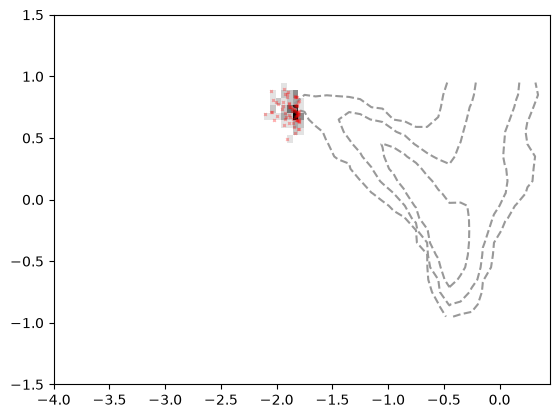

In [8]:
s = (selection['N2'] < -1.8) & (selection['R3'] < 1)
plt.contour(x_centers, y_centers, H, [10, 100, 1000], origin='lower', linestyles='--', colors='0.6')
plt.hist2d(selection[s]['N2'], selection[s]['R3'], bins=(np.linspace(-4, -1.5, 50), np.linspace(-1.5, 1.5, 50)), cmap='gray_r')
plt.plot(selection[s]['N2'], selection[s]['R3'], 'x', color='red', markersize=2, alpha=0.3)

There are far fewer in this catalog. This makes me dubious of the values in the emfit catalog. I could try a crossmatch and/or retrieve the actual spectra of the interesting sources and check them individually.